In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
mpl.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "savefig.dpi": 300,
})


In [3]:
experiment_name = 'lin_reg'
data_dir = Path(f"indicator_data/{experiment_name}")

data = []

for file in os.listdir(data_dir):
    df = pd.read_csv(data_dir / file)
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    
    data += [df]


In [4]:
# Select an illustrative curve
df = data[11]

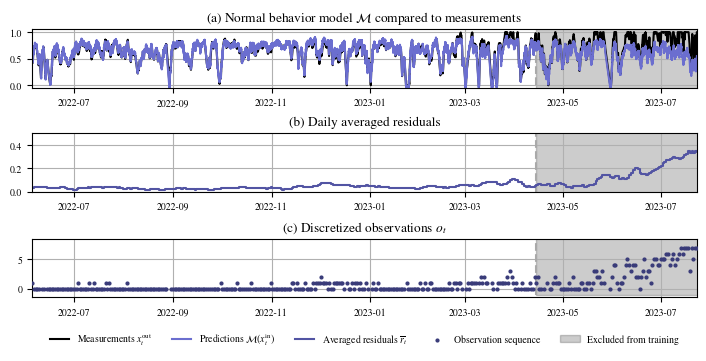

In [5]:
from cycler import cycler
import numpy as np
import itertools

cmap = plt.cm.tab20b
color_cycle = itertools.cycle([cmap.colors[2], cmap.colors[1], cmap.colors[0]])
plt.rcParams["axes.prop_cycle"] = cycler(color=cmap.colors)

window = 6 * 24 * 7
fig, ax = plt.subplots(3, 1, figsize=(7, 3.5), constrained_layout=True)



handles_dict = {}
x = pd.to_datetime(df.time_stamp).to_numpy()
y = np.convolve(df.residual, np.ones(window)/window, mode='valid')
cutoff = df['training_cutoff'].iloc[0]
test_start = df['test_period_start'].iloc[0]

score = r2_score(df.target[:cutoff], df.predictions[:cutoff])



ax[0].set_title('(a) Normal behavior model $\\mathcal{M}$ compared to measurements')
ax[0].vlines(x[cutoff], 0, 1, 'darkgrey', linestyles='dashed')
ax[0].fill_betweenx([-1,2], x[cutoff], x[-1], color='black', alpha=0.2)
handles_dict['Measurements $x_t^\\text{out}$'] = ax[0].plot(x, df.target, color='black')[0]
line, = ax[0].plot(x, df.predictions, color=next(color_cycle), linestyle='solid')
handles_dict['Predictions $\\mathcal{M}(x_t^\\text{in})$'] = line
ax[0].grid()
ax[0].set_ylim(-0.05,1.05)



batch_size = 6 * 24
ax[1].set_title('(b) Daily averaged residuals')
ax[1].vlines(x[cutoff], 0, 1, 'darkgray', linestyles='dashed')
ax[1].grid()
ax[1].fill_betweenx([-1,2], x[cutoff], x[-1], color='black', alpha=0.2)
handles_dict['Averaged residuals $\\overline{r}_t$'] = ax[1].step(x[window-1::batch_size], y[::batch_size],color=next(color_cycle),)[0]
ax[1].set_ylim(0,0.5)


bins = np.linspace(0,.35, 8)
ys = df["residual"].to_numpy()
xs_batched = x[::batch_size]
ys_batched = np.convolve(ys, np.ones(batch_size)/batch_size, mode='valid')[::batch_size]
ys_batched = np.concat([ys_batched, [1.0]])
observation_sequence = np.digitize(ys_batched, bins, right=True) - 1
observation_sequence[ys_batched >= 0.99] = 0

markersize = 4
handles_dict['Observation sequence'] = ax[2].scatter(xs_batched, observation_sequence, color=next(color_cycle), s=markersize, zorder=5)
ax[2].set_title('(c) Discretized observations $o_t$')
ax[2].vlines(x[cutoff], -1, 10, 'darkgrey', linestyles='dashed')
handles_dict['Excluded from training'] = ax[2].fill_betweenx([-1,10], x[cutoff], x[-1], color='black', alpha=0.2)
ax[2].grid()
ax[2].set_ylim(-1.5,8.5)
ax[2].legend(
    handles=handles_dict.values(),
    labels=handles_dict.keys(),
    loc='lower center',
    ncol=len(handles_dict),      # multiple columns if needed
    bbox_to_anchor=(0.5, -1.0), # below the axes
    frameon=False
)

for _ax in ax:
    _ax.set_xlim(x[window - 1], x[-window])



ax[-1]

plt.savefig('plots/sequence_preprocessing.pdf', bbox_inches='tight')
plt.show()


In [6]:
for i, c in enumerate(cmap.colors[:4]):
    print(f'\\definecolor{{blue{i}}}{{rgb}}{{{c[0]}, {c[1]}, {c[2]}}}')

\definecolor{blue0}{rgb}{0.2235294117647059, 0.23137254901960785, 0.4745098039215686}
\definecolor{blue1}{rgb}{0.3215686274509804, 0.32941176470588235, 0.6392156862745098}
\definecolor{blue2}{rgb}{0.4196078431372549, 0.43137254901960786, 0.8117647058823529}
\definecolor{blue3}{rgb}{0.611764705882353, 0.6196078431372549, 0.8705882352941177}
